In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [41]:
df = pd.read_csv('telco.csv')
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [42]:
df.tail()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
7038,2569-WGERO,Female,30,No,No,No,No,0,United States,California,...,0,1639.44,3039.53,5,Stayed,No,45,5306,NaN,NaN
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2,United States,California,...,0,865.20,2807.47,3,Stayed,No,59,2140,NaN,NaN
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2,United States,California,...,0,2135.52,9453.04,4,Stayed,No,71,5560,NaN,NaN
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2,United States,California,...,0,0.00,319.21,4,Stayed,No,59,2793,NaN,NaN
7042,3186-AJIEK,Male,44,No,No,No,No,0,United States,California,...,0,2043.36,8887.86,4,Stayed,No,38,5097,NaN,NaN


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   str    
 4   Senior Citizen                     7043 non-null   str    
 5   Married                            7043 non-null   str    
 6   Dependents                         7043 non-null   str    
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   str    
 9   State                              7043 non-null   str    
 10  City                               7043 non-null   str    
 11  Zip Code                           7043 non-null   int64  
 12  Lat

In [44]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [45]:
df.shape

(7043, 50)

In [46]:
df.astype

<bound method NDFrame.astype of      Customer ID  Gender  Age Under 30 Senior Citizen Married Dependents  \
0     8779-QRDMV    Male   78       No            Yes      No         No   
1     7495-OOKFY  Female   74       No            Yes     Yes        Yes   
2     1658-BYGOY    Male   71       No            Yes      No        Yes   
3     4598-XLKNJ  Female   78       No            Yes     Yes        Yes   
4     4846-WHAFZ  Female   80       No            Yes     Yes        Yes   
...          ...     ...  ...      ...            ...     ...        ...   
7038  2569-WGERO  Female   30       No             No      No         No   
7039  6840-RESVB    Male   38       No             No     Yes        Yes   
7040  2234-XADUH  Female   30       No             No     Yes        Yes   
7041  4801-JZAZL  Female   32       No             No     Yes        Yes   
7042  3186-AJIEK    Male   44       No             No      No         No   

      Number of Dependents        Country       State  

In [47]:
df.isna().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [48]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [49]:
df.isna().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [50]:
df

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,Female,30,No,No,No,No,0,United States,California,...,0,1639.44,3039.53,5,Stayed,No,45,5306,NaN,NaN
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2,United States,California,...,0,865.20,2807.47,3,Stayed,No,59,2140,NaN,NaN
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2,United States,California,...,0,2135.52,9453.04,4,Stayed,No,71,5560,NaN,NaN
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2,United States,California,...,0,0.00,319.21,4,Stayed,No,59,2793,NaN,NaN


In [51]:
df.isna().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   str    
 4   Senior Citizen                     7043 non-null   str    
 5   Married                            7043 non-null   str    
 6   Dependents                         7043 non-null   str    
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   str    
 9   State                              7043 non-null   str    
 10  City                               7043 non-null   str    
 11  Zip Code                           7043 non-null   int64  
 12  Lat

In [53]:
df['Offer'] = df['Offer'].fillna('No offer')

In [54]:
df['Offer']

0       No offer
1        Offer E
2        Offer D
3        Offer C
4        Offer C
          ...   
7038    No offer
7039     Offer C
7040    No offer
7041    No offer
7042    No offer
Name: Offer, Length: 7043, dtype: str

In [55]:
df.isna().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                   0
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [56]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [57]:
df['Internet Type'] = df['Internet Type'].fillna('No Internet')

In [58]:
df['Churn Category'] = df['Churn Category'].fillna('No Churn Category')
df['Churn Reason'] = df['Churn Reason'].fillna('No Reason')

In [59]:
df.isna().sum()

Customer ID                          0
Gender                               0
Age                                  0
Under 30                             0
Senior Citizen                       0
Married                              0
Dependents                           0
Number of Dependents                 0
Country                              0
State                                0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Population                           0
Quarter                              0
Referred a Friend                    0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download  

In [60]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [61]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='str')

In [62]:
drop_cols = ['Customer ID', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude',
             'Churn Score', 'Churn Category', 'Churn Reason', 'Customer Status']
df_clean = df.drop(columns=drop_cols)
df_clean['Churn Label'] = df_clean['Churn Label'].map({'Yes': 1, 'No': 0})

categorical_cols = df_clean.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)

(7043, 46)


In [63]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [64]:
df_encoded

,Age,Number of Dependents,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,...,Premium Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check
0,78,0,68701,0,1,0.00,8,39.65,39.65,0.00,...,False,False,True,False,False,False,False,True,False,False
1,74,1,55668,1,8,48.85,17,80.65,633.30,0.00,...,False,False,False,False,True,False,False,True,True,False
2,71,3,47534,0,18,11.33,52,95.45,1752.55,45.61,...,False,True,True,True,True,False,False,True,False,False
3,78,1,27778,1,25,19.76,12,98.50,2514.50,13.43,...,False,True,True,False,True,False,False,True,False,False
4,80,1,26265,1,37,6.33,14,76.50,2868.15,0.00,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,30,0,2182,0,72,22.77,0,21.15,1419.40,19.31,...,False,False,False,False,False,False,True,True,False,False
7039,38,2,18980,1,24,36.05,24,84.80,1990.50,48.23,...,True,True,True,True,True,True,False,True,False,True
7040,30,2,42,4,72,29.66,59,103.20,7362.90,45.38,...,False,True,True,True,True,True,False,True,True,False
7041,32,2,301,1,11,0.00,17,29.60,346.45,27.24,...,False,False,False,False,True,False,False,True,False,False


In [65]:
leakage_and_id_cols = [
    'Customer ID', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude',
    'Customer Status', 'Churn Score', 'Churn Category', 'Churn Reason',
    'Satisfaction Score', 'Churn Label'
]

X = df_encoded.drop(columns=leakage_and_id_cols, errors='ignore')
y = df_encoded['Churn Label']

In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [67]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train , y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [68]:
y_pred = model.predict(X_test)


In [69]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
accuracy_score(y_test , y_pred)
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86      1009
           1       0.67      0.44      0.53       400

    accuracy                           0.78      1409
   macro avg       0.74      0.68      0.69      1409
weighted avg       0.77      0.78      0.76      1409



In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled

array([[ 1.58666576, -0.48648852,  1.24652311, ..., -1.19299028,
        -0.80698882, -0.2413025 ],
       [ 1.04880685, -0.48648852, -1.045764  , ..., -1.19299028,
        -0.80698882, -0.2413025 ],
       [-1.1026288 , -0.48648852, -0.01755002, ...,  0.8382298 ,
         1.23917455, -0.2413025 ],
       ...,
       [-1.1623909 , -0.48648852, -1.03940216, ...,  0.8382298 ,
        -0.80698882, -0.2413025 ],
       [-0.50500779,  2.64833002,  0.24177724, ..., -1.19299028,
         1.23917455, -0.2413025 ],
       [-0.9831046 , -0.48648852,  0.72047001, ..., -1.19299028,
         1.23917455, -0.2413025 ]], shape=(1409, 44))

In [71]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_scaled , y_train)
y_pred_knn = model_knn.predict(X_test_scaled)
accuracy_score(y_test , y_pred_knn)
print(classification_report(y_test , y_pred_knn))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1009
           1       0.64      0.65      0.64       400

    accuracy                           0.80      1409
   macro avg       0.75      0.75      0.75      1409
weighted avg       0.80      0.80      0.80      1409



In [72]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()
model_NB.fit(X_train , y_train)
y_pred_NB = model_NB.predict(X_test)
print(classification_report(y_test , y_pred_NB))

              precision    recall  f1-score   support

           0       0.90      0.67      0.77      1009
           1       0.49      0.81      0.61       400

    accuracy                           0.71      1409
   macro avg       0.70      0.74      0.69      1409
weighted avg       0.78      0.71      0.73      1409



In [73]:
from sklearn.tree import DecisionTreeClassifier
model_DT = DecisionTreeClassifier(random_state = 42)
model_DT.fit(X_train_scaled , y_train)
y_pred_DT = model_DT.predict(X_test_scaled)
print(classification_report(y_test , y_pred_DT))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1009
           1       0.61      0.61      0.61       400

    accuracy                           0.78      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.78      0.78      0.78      1409



In [74]:
from sklearn.svm import SVC
model_svm = SVC()
model_svm.fit(X_train_scaled , y_train)
y_pred_svm = model_svm.predict(X_test_scaled)
print(classification_report(y_test , y_pred_svm))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1009
           1       0.76      0.62      0.69       400

    accuracy                           0.84      1409
   macro avg       0.81      0.77      0.79      1409
weighted avg       0.83      0.84      0.83      1409



In [75]:
from sklearn.ensemble import RandomForestClassifier
rf_model= RandomForestClassifier(
    n_estimators = 100,
    max_depth = None ,
    random_state = 42,
)
rf_model.fit(X_train_scaled , y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
print(classification_report(y_test , y_pred_rf))



              precision    recall  f1-score   support

           0       0.85      0.93      0.89      1009
           1       0.78      0.60      0.68       400

    accuracy                           0.84      1409
   macro avg       0.82      0.77      0.79      1409
weighted avg       0.83      0.84      0.83      1409



In [76]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators = 100 , learning_rate = 0.1 , max_depth = 3 , use_label_encoder = False , eval_metric = 'logloss' , random_state = 42)
xgb_model.fit(X_train , y_train)
y_test_pred_xgb = xgb_model.predict(X_test)
y_train_pred_xgb = xgb_model.predict(X_train)
accuracy_score(y_train , y_train_pred_xgb)
accuracy_score(y_test , y_test_pred_xgb)

0.8530872959545777

In [77]:
from sklearn.model_selection import cross_val_score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scores = cross_val_score(xgb_model , X_scaled , y , cv = 5 , scoring = 'accuracy')
scores

array([0.54293825, 0.83250532, 0.82966643, 0.82244318, 0.83309659])

In [78]:
print("overall average:" , scores.mean())

overall average: 0.7721299559649009


In [79]:
from sklearn.model_selection import RandomizedSearchCV
classifier = RandomizedSearchCV((xgb_model) , {
    'c' : [1 ,10 , 20, 30],
    'kernel' : ['rbf' , 'linear'],
} , n_iter = 4 , cv = 5 , return_train_score = False)
classifier.fit(X,y)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'c': [1, 10, ...], 'kernel': ['rbf', 'linear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``ref

In [80]:
from sklearn.metrics import classification_report, roc_auc_score

# Direct trained model se predictions
y_pred = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1009
           1       0.78      0.67      0.72       400

    accuracy                           0.85      1409
   macro avg       0.83      0.80      0.81      1409
weighted avg       0.85      0.85      0.85      1409

ROC-AUC Score: 0.9152316650148662


In [81]:
import joblib
joblib.dump(xgb_model, 'churn_xgb_model.pkl')
print("Model Successfully Saved!")

Model Successfully Saved!


In [82]:
import joblib
import pandas as pd


loaded_model = joblib.load("churn_xgb_model.pkl")


feature_importances = pd.Series(
    loaded_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)


print("=" * 50)
print("       PROJECT COMPLETED: CHURN MODELING PIPELINE")
print("=" * 50)
print(f"✓ Model Artifact Saved : 'churn_xgb_model.pkl'")
print(f"✓ Total Features Used  : {X_train.shape[1]}")
print(f"✓ Test Performance     : ROC-AUC = {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]):.4f}")
print("-" * 50)
print("\nTop 5 Most Important Factors Driving Customer Churn:")
print(feature_importances.head(5).to_string())
print("=" * 50)

       PROJECT COMPLETED: CHURN MODELING PIPELINE
✓ Model Artifact Saved : 'churn_xgb_model.pkl'
✓ Total Features Used  : 44
✓ Test Performance     : ROC-AUC = 0.9152
--------------------------------------------------

Top 5 Most Important Factors Driving Customer Churn:
Contract_Two Year             0.157882
Internet Type_Fiber Optic     0.142274
Contract_One Year             0.094854
Payment Method_Credit Card    0.066650
Avg Monthly GB Download       0.066155


In [83]:
def predict_churn(customer_data):

    probability = loaded_model.predict_proba(customer_data)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    return prediction, probability

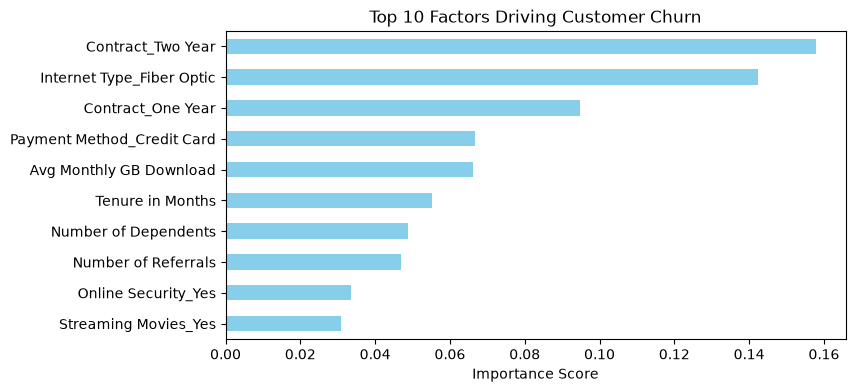

In [84]:
plt.figure(figsize=(8, 4))
feature_importances.head(10).plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Factors Driving Customer Churn')
plt.xlabel('Importance Score')
plt.show()

In [85]:
!pip install -q gradio

import gradio as gr
import pandas as pd
import joblib

model = joblib.load("churn_xgb_model.pkl")

def predict_churn_ui(contract, internet_type, payment_method, gb_download, tenure, dependents, referrals):

    input_data = pd.DataFrame(0, index=[0], columns=X_train.columns)


    if f"Contract_{contract}" in input_data.columns:
        input_data[f"Contract_{contract}"] = 1
    if f"Internet Type_{internet_type}" in input_data.columns:
        input_data[f"Internet Type_{internet_type}"] = 1
    if f"Payment Method_{payment_method}" in input_data.columns:
        input_data[f"Payment Method_{payment_method}"] = 1

    if "Avg Monthly GB Download" in input_data.columns:
        input_data["Avg Monthly GB Download"] = gb_download
    if "Tenure in Months" in input_data.columns:
        input_data["Tenure in Months"] = tenure
    if "Number of Dependents" in input_data.columns:
        input_data["Number of Dependents"] = dependents
    if "Number of Referrals" in input_data.columns:
        input_data["Number of Referrals"] = referrals

    prob = model.predict_proba(input_data)[0][1]
    status = " High Risk of Churn" if prob >= 0.5 else "✅ Low Risk (Likely to Stay)"

    return f"{status}\n\nProbability of Churn: {prob:.2%}"

demo = gr.Interface(
    fn=predict_churn_ui,
    inputs=[
        gr.Dropdown(["Month-to-Month", "One Year", "Two Year"], label="Contract Type", value="Month-to-Month"),
        gr.Dropdown(["Fiber Optic", "DSL", "None"], label="Internet Type", value="Fiber Optic"),
        gr.Dropdown(["Bank Transfer", "Credit Card", "Electronic Check", "Mailed Check"], label="Payment Method", value="Electronic Check"),
        gr.Slider(0, 100, value=25, step=1, label="Avg Monthly GB Download"),
        gr.Slider(1, 72, value=12, step=1, label="Tenure (Months)"),
        gr.Slider(0, 10, value=0, step=1, label="Number of Dependents"),
        gr.Slider(0, 15, value=0, step=1, label="Number of Referrals"),
    ],
    outputs="text",
    title="Customer Churn Prediction App",
    description="Adjust customer attributes to evaluate churn likelihood in real-time."
)

demo.launch(share=True, debug=True)

'pip' is not recognized as an internal or external command,
operable program or batch file.


ModuleNotFoundError: No module named 'gradio'

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
feature_importances.head(10).plot(kind='barh', color='#3498db', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 10 Key Factors Driving Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()

plt.savefig('churn_feature_importance.png', dpi=300)
plt.show()
print(" Saved 'churn_feature_importance.png' successfully.")

In [ ]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [ ]:
total_customers = len(y_test)
actual_churners = y_test.sum()

cost_of_retention_campaign = 50
customer_lifetime_value = 1000

y_pred = loaded_model.predict(X_test)
tp = ((y_pred == 1) & (y_test == 1)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()

revenue_saved = tp * customer_lifetime_value
campaign_cost = (tp + fp) * cost_of_retention_campaign
net_profit = revenue_saved - campaign_cost

print(f" Saved Revenue from Retention : ${revenue_saved:,.2f}")
print(f" Cost of Target Campaigns     : ${campaign_cost:,.2f}")
print(f" Net Business Value Created   : ${net_profit:,.2f}")